In [7]:
!pip install pandas numpy scikit-learn matplotlib joblib -q

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [8]:
base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles"

files = {
    "demo": f"{base_url}/DEMO_J.XPT",
    "bmx": f"{base_url}/BMX_J.XPT",
    "diq": f"{base_url}/DIQ_J.XPT",
    "bpq": f"{base_url}/BPQ_J.XPT",
    "mcq": f"{base_url}/MCQ_J.XPT",
    "paq": f"{base_url}/PAQ_J.XPT",
    "pfq": f"{base_url}/PFQ_J.XPT",
}

def read_xpt(url):
    return pd.read_sas(url, format="xport")

demo = read_xpt(files["demo"])
bmx  = read_xpt(files["bmx"])
diq  = read_xpt(files["diq"])
bpq  = read_xpt(files["bpq"])
mcq  = read_xpt(files["mcq"])
paq  = read_xpt(files["paq"])
pfq  = read_xpt(files["pfq"])

print(demo.shape, bmx.shape, diq.shape, bpq.shape, mcq.shape, paq.shape, pfq.shape)

(9254, 46) (8704, 21) (8897, 54) (6161, 11) (8897, 76) (5856, 17) (8421, 36)


In [9]:
demo_keep = demo[[
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "WTMEC2YR",
    "SDMVSTRA",
    "SDMVPSU"
]].copy()

bmx_keep = bmx[["SEQN", "BMXBMI"]].copy()

diq_keep = diq[["SEQN", "DIQ010"]].copy()

bpq_keep = bpq[["SEQN", "BPQ020"]].copy()

mcq_keep = mcq[["SEQN", "MCQ160F"]].copy()

paq_keep = paq[[
    "SEQN",
    "PAQ605",
    "PAQ620",
    "PAQ635",
    "PAQ650",
    "PAQ665"
]].copy()

pfq_keep = pfq[[
    "SEQN",
    "PFQ061B",
    "PFQ061C",
    "PFQ061D",
    "PFQ061E",
    "PFQ061F"
]].copy()

df = demo_keep.merge(bmx_keep, on="SEQN", how="left")
df = df.merge(diq_keep, on="SEQN", how="left")
df = df.merge(bpq_keep, on="SEQN", how="left")
df = df.merge(mcq_keep, on="SEQN", how="left")
df = df.merge(paq_keep, on="SEQN", how="left")
df = df.merge(pfq_keep, on="SEQN", how="left")

print(df.shape)
df.head()

(9254, 22)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,WTMEC2YR,SDMVSTRA,SDMVPSU,BMXBMI,DIQ010,...,PAQ605,PAQ620,PAQ635,PAQ650,PAQ665,PFQ061B,PFQ061C,PFQ061D,PFQ061E,PFQ061F
0,93703.0,2.0,2.0,6.0,NaN,8539.731348,145.0,2.0,17.5,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,2.0,1.0,3.0,NaN,42566.614750,143.0,1.0,15.7,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,66.0,2.0,4.0,2.0,8338.419786,145.0,2.0,31.7,2.0,...,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0
3,93706.0,18.0,1.0,6.0,NaN,8723.439814,134.0,2.0,21.5,2.0,...,2.0,2.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN
4,93707.0,13.0,1.0,7.0,NaN,7064.609730,138.0,1.0,18.1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df = df[df["RIDAGEYR"] >= 60].copy()

print("Older adult sample size before cleaning:", df.shape[0])

Older adult sample size before cleaning: 2150


In [11]:
# Basic demographics
df["age"] = df["RIDAGEYR"]

df["sex"] = df["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

df["race_ethnicity"] = df["RIDRETH3"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other race or multiracial"
})

df["education"] = df["DMDEDUC2"].map({
    1: "Less than 9th grade",
    2: "9th to 11th grade",
    3: "High school or GED",
    4: "Some college or AA degree",
    5: "College graduate or above"
})

df["bmi"] = df["BMXBMI"]

# Chronic disease indicators
df["diabetes"] = df["DIQ010"].map({
    1: "Yes",
    2: "No",
    3: "Borderline"
})

df["hypertension"] = df["BPQ020"].map({
    1: "Yes",
    2: "No"
})

df["stroke"] = df["MCQ160F"].map({
    1: "Yes",
    2: "No"
})

In [13]:
pa_vars = ["PAQ605", "PAQ620", "PAQ635", "PAQ650", "PAQ665"]

# NHANES convention here: 1 = Yes, 2 = No, 7 = Refused, 9 = Don't know.
for v in pa_vars:
    df[v] = df[v].replace({7: np.nan, 9: np.nan})

# Start with missing values as object dtype, then fill Yes/No based on PA responses.
df["physically_active"] = pd.Series(pd.NA, index=df.index, dtype="object")

# If any PA item is Yes, classify as physically active.
df.loc[df[pa_vars].eq(1).any(axis=1), "physically_active"] = "Yes"

# If all non-missing PA items are No and the person has at least one non-missing PA response, classify as not physically active.
has_any_pa_response = df[pa_vars].notna().any(axis=1)
all_reported_pa_no = df[pa_vars].eq(2).all(axis=1)

df.loc[has_any_pa_response & all_reported_pa_no, "physically_active"] = "No"

df["physically_active"].value_counts(dropna=False)

,count
physically_active,
Yes,1351
No,796
<NA>,3


In [15]:
pfq_map = {
    "PFQ061B": "diff_walk_quarter_mile",
    "PFQ061C": "diff_walk_10_steps",
    "PFQ061D": "diff_stoop",
    "PFQ061E": "diff_lift_carry",
    "PFQ061F": "diff_household_chores"
}

# For PFQ061 items:
# 1 = No difficulty
# 2 = Some difficulty
# 3 = Much difficulty
# 4 = Unable to do
# 5 = Do not do this activity
# 7 = Refused
# 9 = Don't know
#
# For this capstone, 2/3/4 are treated as difficulty.
# 1 is treated as no difficulty.
# 5/7/9 are treated as missing because "do not do this activity" may not always mean limitation.
for raw_var, new_var in pfq_map.items():
    df[raw_var] = df[raw_var].replace({5: np.nan, 7: np.nan, 9: np.nan})

    df[new_var] = pd.Series(pd.NA, index=df.index, dtype="object")
    df.loc[df[raw_var] == 1, new_var] = "No"
    df.loc[df[raw_var].isin([2, 3, 4]), new_var] = "Yes"

difficulty_vars = list(pfq_map.values())

# Low physical activity deficit
df["low_physical_activity_deficit"] = np.nan
df.loc[df["physically_active"] == "Yes", "low_physical_activity_deficit"] = 0
df.loc[df["physically_active"] == "No", "low_physical_activity_deficit"] = 1

# Physical function difficulty deficits
for v in difficulty_vars:
    deficit_name = v + "_deficit"
    df[deficit_name] = np.nan
    df.loc[df[v] == "No", deficit_name] = 0
    df.loc[df[v] == "Yes", deficit_name] = 1

deficit_vars = (
    ["low_physical_activity_deficit"] +
    [v + "_deficit" for v in difficulty_vars]
)

# Require at least 5 of 6 frailty proxy components to avoid unstable classification.
df["n_nonmissing_deficits"] = df[deficit_vars].notna().sum(axis=1)
df["deficit_count"] = df[deficit_vars].sum(axis=1, skipna=True)

df = df[df["n_nonmissing_deficits"] >= 5].copy()

# Simplified frailty proxy:
# 0 deficits = Robust
# 1-2 deficits = Pre-frail
# 3+ deficits = Frail
df["frailty_status"] = pd.cut(
    df["deficit_count"],
    bins=[-1, 0, 2, 6],
    labels=["Robust", "Pre-frail", "Frail"]
)

print("Frailty proxy distribution:")
print(df["frailty_status"].value_counts(dropna=False))

print("\nNonmissing deficit item distribution:")
print(df["n_nonmissing_deficits"].value_counts().sort_index())

Frailty proxy distribution:
frailty_status
Pre-frail    625
Robust       578
Frail        383
Name: count, dtype: int64

Nonmissing deficit item distribution:
n_nonmissing_deficits
5      75
6    1511
Name: count, dtype: int64


In [16]:
predictors = [
    "age",
    "sex",
    "race_ethnicity",
    "education",
    "bmi",
    "diabetes",
    "hypertension",
    "stroke",
    "physically_active",
    "diff_walk_quarter_mile",
    "diff_walk_10_steps",
    "diff_stoop",
    "diff_lift_carry",
    "diff_household_chores",
]

analytic = df[predictors + ["frailty_status"]].copy()

print("Sample size before dropping missing predictors/outcome:", analytic.shape[0])

# Drop records with missing predictors or outcome for this simple capstone model.
analytic = analytic.dropna().copy()

print("Final analytic sample size:", analytic.shape[0])
print("\nOutcome distribution:")
print(analytic["frailty_status"].value_counts())

print("\nOutcome distribution, proportion:")
print(analytic["frailty_status"].value_counts(normalize=True).round(3))

analytic.head()

Sample size before dropping missing predictors/outcome: 1586
Final analytic sample size: 1409

Outcome distribution:
frailty_status
Pre-frail    553
Robust       527
Frail        329
Name: count, dtype: int64

Outcome distribution, proportion:
frailty_status
Pre-frail    0.392
Robust       0.374
Frail        0.233
Name: proportion, dtype: float64


,age,sex,race_ethnicity,education,bmi,diabetes,hypertension,stroke,physically_active,diff_walk_quarter_mile,diff_walk_10_steps,diff_stoop,diff_lift_carry,diff_household_chores,frailty_status
2,66.0,Female,Non-Hispanic Black,9th to 11th grade,31.7,No,Yes,No,Yes,No,No,No,No,No,Robust
5,66.0,Female,Non-Hispanic Asian,Less than 9th grade,23.7,Borderline,Yes,No,Yes,Yes,Yes,Yes,No,No,Frail
10,67.0,Male,Non-Hispanic White,High school or GED,23.5,No,No,No,Yes,No,No,No,No,No,Robust
12,71.0,Male,Other race or multiracial,High school or GED,22.5,No,No,No,Yes,Yes,No,No,Yes,No,Pre-frail
13,61.0,Male,Non-Hispanic Asian,College graduate or above,30.7,No,No,No,Yes,No,No,No,No,No,Robust


In [17]:
X = analytic[predictors].copy()
y = analytic["frailty_status"].copy()

# One-hot encode categorical predictors.
X_encoded = pd.get_dummies(X, drop_first=False)

feature_columns = X_encoded.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix, labels = Robust, Pre-frail, Frail:")
print(confusion_matrix(y_test, y_pred, labels=["Robust", "Pre-frail", "Frail"]))

Accuracy: 0.972

Classification report:
              precision    recall  f1-score   support

       Frail       0.95      0.98      0.96        82
   Pre-frail       0.98      0.94      0.96       139
      Robust       0.97      1.00      0.99       132

    accuracy                           0.97       353
   macro avg       0.97      0.97      0.97       353
weighted avg       0.97      0.97      0.97       353


Confusion matrix, labels = Robust, Pre-frail, Frail:
[[132   0   0]
 [  4 131   4]
 [  0   2  80]]


In [18]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
29,diff_stoop_Yes,0.132432
28,diff_stoop_No,0.131289
25,diff_walk_quarter_mile_Yes,0.101830
24,diff_walk_quarter_mile_No,0.097779
23,physically_active_Yes,0.095765
22,physically_active_No,0.093398
31,diff_lift_carry_Yes,0.066091
30,diff_lift_carry_No,0.059593
32,diff_household_chores_No,0.049241
33,diff_household_chores_Yes,0.048097


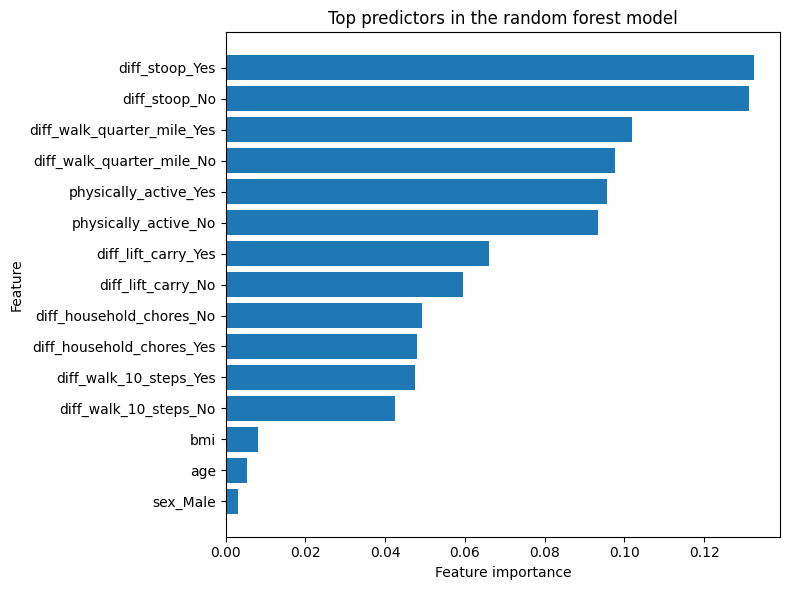

In [19]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top predictors in the random forest model")
plt.tight_layout()
plt.show()

In [20]:
os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

joblib.dump(rf_model, "models/frailty_model.pkl")
joblib.dump(feature_columns, "models/feature_columns.pkl")

analytic.to_csv("data/cleaned_nhanes_frailty.csv", index=False)

print("Saved files:")
print("models/frailty_model.pkl")
print("models/feature_columns.pkl")
print("data/cleaned_nhanes_frailty.csv")

Saved files:
models/frailty_model.pkl
models/feature_columns.pkl
data/cleaned_nhanes_frailty.csv


In [21]:
from google.colab import files

files.download("models/frailty_model.pkl")
files.download("models/feature_columns.pkl")
files.download("data/cleaned_nhanes_frailty.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>